In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

In [2]:
CHAR_SEP = '.'

In [3]:
with open('names.txt', 'r') as f:
    names = f.read().splitlines()
    chars = sorted(set(char for name in names for char in name))

In [4]:
names = [f"{CHAR_SEP}{name}{CHAR_SEP}" for name in names]
names[:5]

['.emma.', '.olivia.', '.ava.', '.isabella.', '.sophia.']

In [5]:
itoc = {}
itoc[0] = CHAR_SEP
for i, c in enumerate(chars, 1):
    itoc[i] = c
itoc

{0: '.',
 1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z'}

In [6]:
ctoi = {c: i for i, c in itoc.items()}
ctoi

{'.': 0,
 'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26}

In [7]:
counts = torch.zeros((27, 27))
for name in names:
    for c1, c2 in zip(name, name[1:]):
        counts[ctoi[c1], ctoi[c2]] += 1
counts.shape

torch.Size([27, 27])

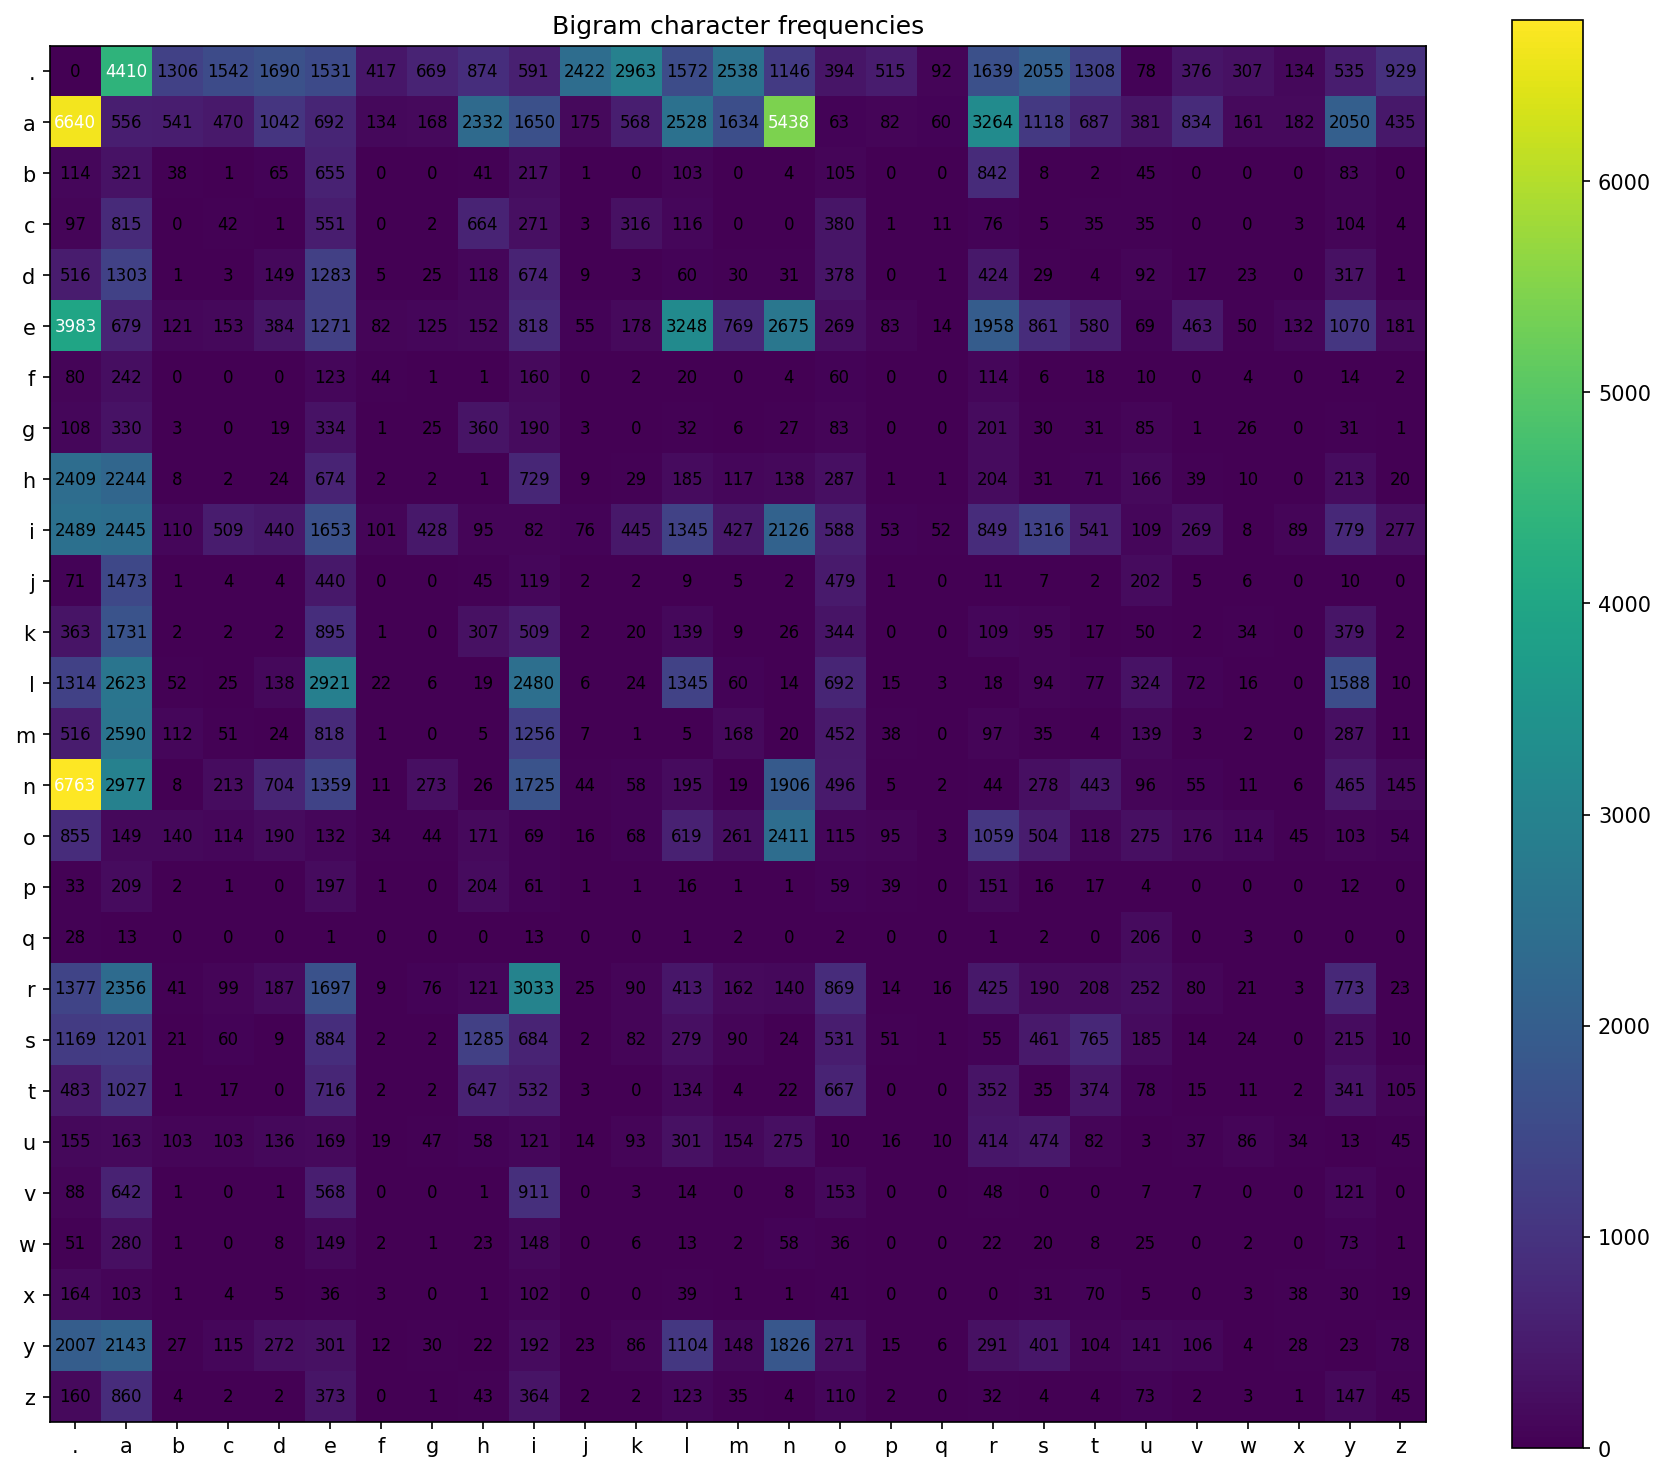

In [8]:
fig, ax = plt.subplots(figsize=(12, 10), dpi=150)

im = ax.imshow(counts, cmap="viridis")

for i in range(counts.shape[0]):
    for j in range(counts.shape[1]):
        value = int(counts[i, j])
        color = "white" if value > counts.max() / 2 else "black"

        ax.text(j, i, value,
                ha="center", va="center",
                color=color, fontsize=8)

ax.set_xticks(range(len(ctoi)))
ax.set_yticks(range(len(ctoi)))

ax.set_xticklabels(list(ctoi.keys()), rotation=0)
ax.set_yticklabels(list(ctoi.keys()), rotation=0)

ax.set_title("Bigram character frequencies")

fig.colorbar(im, ax=ax)

fig.tight_layout()
plt.show()

In [9]:
probs = counts.float()
probs /= probs.sum(dim=1, keepdim=True)
probs.shape

torch.Size([27, 27])

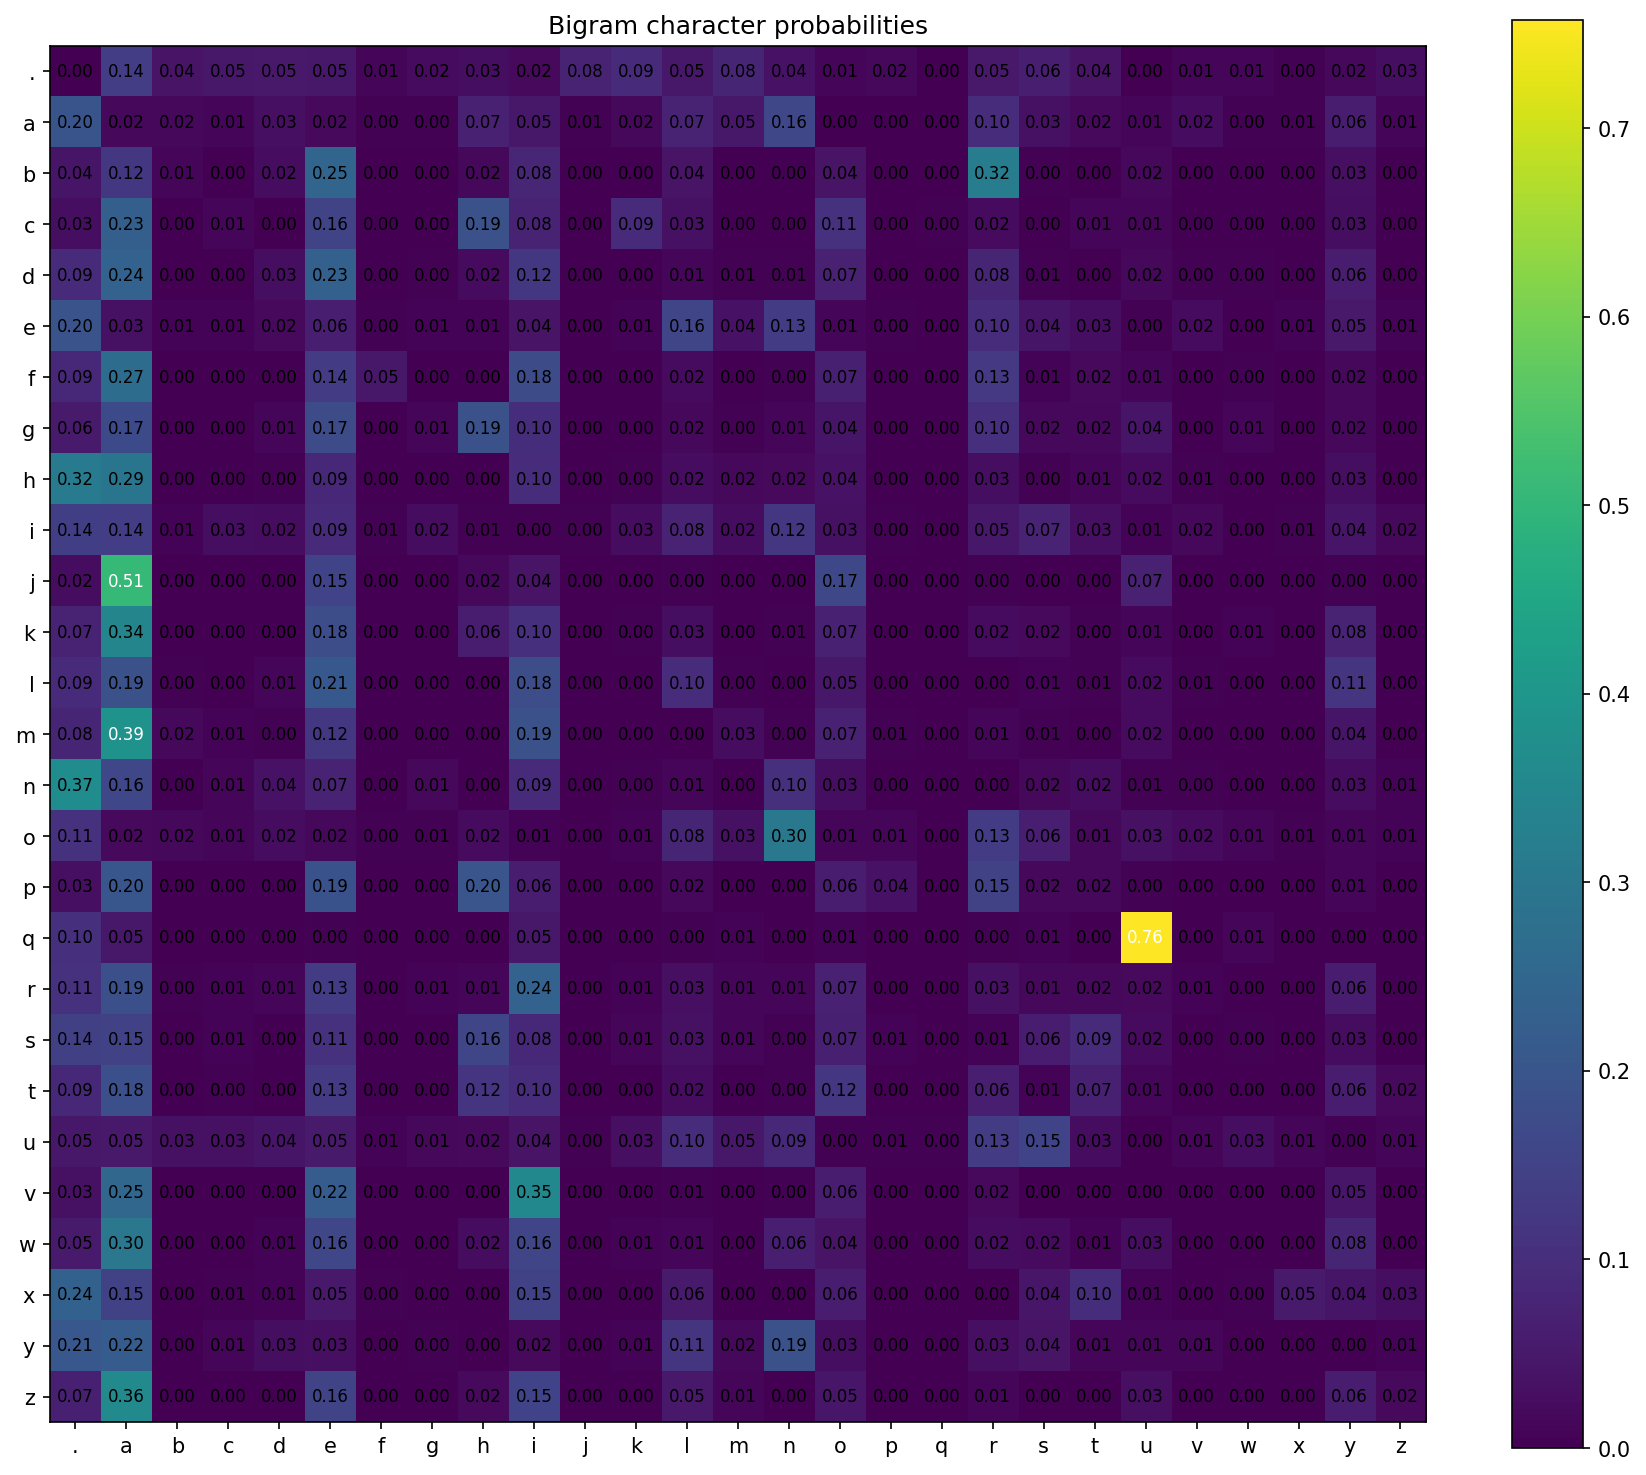

In [10]:
fig, ax = plt.subplots(figsize=(12, 10), dpi=150)

im = ax.imshow(probs, cmap="viridis")

for i in range(probs.shape[0]):
    for j in range(probs.shape[1]):
        prob = probs[i, j]
        color = "white" if prob > probs.max() / 2 else "black"

        ax.text(j, i, f"{prob:.2f}",
                ha="center", va="center",
                color=color, fontsize=8)

ax.set_xticks(range(len(ctoi)))
ax.set_yticks(range(len(ctoi)))

ax.set_xticklabels(list(ctoi.keys()), rotation=0)
ax.set_yticklabels(list(ctoi.keys()), rotation=0)

ax.set_title("Bigram character probabilities")

fig.colorbar(im, ax=ax)

fig.tight_layout()
plt.show()

#### Inference

In [11]:
g = torch.Generator()
g.manual_seed(1776892230)

gen_names = []

for k in range(10):
    i = 0
    gen_name = ""
    while True:
        i = torch.multinomial(probs[i, :], 1, replacement=True, generator=g).item()
        c = itoc[i]
        if c == CHAR_SEP:
            gen_names.append(gen_name) 
            break
        gen_name += c
gen_names

['can',
 'joinune',
 'sheema',
 'ste',
 'aiselyaryded',
 'tell',
 'dheelt',
 'tarensyanel',
 'kaylolsha',
 'aha']

#### Evaluation

In [12]:
nll = 0.0
count = 0
for name in names:
    i = 0
    for c in name[1:]:
        nll += -(probs[i, ctoi[c]].log())
        i = ctoi[c]
        count += 1
nll / count

tensor(2.4541)

### FFN equivalence with bigram modeling

In [13]:
xs = []
ys = []

for name in names:
    prev_c = name[0]
    for c in name[1:]:
        xs.append(ctoi[prev_c])
        ys.append(ctoi[c])
        prev_c = c

xs = F.one_hot(torch.tensor(xs), num_classes=len(ctoi)).float()
ys = torch.tensor(ys).long()

In [14]:
import functools
import operator

W1 = torch.randn((27, 27))
W1.requires_grad = True
b1 = torch.randn((27))
b1.requires_grad = True

parameters = [W1, b1]

total = sum((
    functools.reduce(operator.mul, p.shape)
    for p in parameters
))
total

756

In [15]:
epochs = 5000
log_every = 100

lr = 0.1

for epoch in range(epochs):
    # forward pass
    logits = xs @ W1 + b1
    loss   = F.cross_entropy(logits, ys)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # optimize
    for p in parameters:
        p.data += -lr * p.grad

    if epoch % log_every == 0:
        print(f"epoch[{epoch}] loss={loss.item()}")

epoch[0] loss=4.220920085906982
epoch[100] loss=3.5888688564300537
epoch[200] loss=3.3312811851501465
epoch[300] loss=3.1959006786346436
epoch[400] loss=3.1098883152008057
epoch[500] loss=3.0496387481689453
epoch[600] loss=3.003525495529175
epoch[700] loss=2.965942621231079
epoch[800] loss=2.9341373443603516
epoch[900] loss=2.906564950942993
epoch[1000] loss=2.882253646850586
epoch[1100] loss=2.860548496246338
epoch[1200] loss=2.8409862518310547
epoch[1300] loss=2.8232290744781494
epoch[1400] loss=2.8070178031921387
epoch[1500] loss=2.792149066925049
epoch[1600] loss=2.7784578800201416
epoch[1700] loss=2.7658090591430664
epoch[1800] loss=2.754086494445801
epoch[1900] loss=2.743192672729492
epoch[2000] loss=2.7330424785614014
epoch[2100] loss=2.723562002182007
epoch[2200] loss=2.7146859169006348
epoch[2300] loss=2.7063581943511963
epoch[2400] loss=2.6985280513763428
epoch[2500] loss=2.6911513805389404
epoch[2600] loss=2.6841890811920166
epoch[2700] loss=2.6776058673858643
epoch[2800] lo

#### Inference

In [16]:
gen_names = []
for _ in range(10):
    i = 0
    gen_name = ""
    while True:
        xs = F.one_hot(torch.tensor([i]), num_classes=len(ctoi)).float()
        logits = xs @ W1 + b1
        probs = logits.softmax(1)
        i = torch.multinomial(probs, 1, replacement=True, generator=g).item()
        c = itoc[i]
        if c == CHAR_SEP:
            gen_names.append(gen_name)
            break
        gen_name += c
gen_names

['keh',
 'tlieudhsoleqa',
 'avs',
 'in',
 'scyo',
 'krirpi',
 'm',
 'lyilriniyriae',
 'amalasrahr',
 'aiar']

#### Evaluate

In [17]:
nll = 0.0
count = 0
for name in names:
    i = 0
    for c in name[1:]:
        x  = F.one_hot(torch.tensor([i]), num_classes=len(ctoi)).float()
        y  =  torch.tensor([ctoi[c]]).long()
        logits = x @ W1 + b1
        nll += F.cross_entropy(logits, y)
        i = ctoi[c]
        count += 1
nll / count

tensor(2.5868, grad_fn=<DivBackward0>)